## ML Pipeline 1 — Donor lapse prediction

### 1) Problem framing
**Business question:** Which supporters are at risk of lapsing soon, so staff can prioritize outreach and improve donor retention?

**Who cares:** Fundraising/admin staff responsible for donor retention and campaign targeting.

**Prediction target (operational):** Predict whether a supporter will **make a donation in the next 90 days** (binary). If predicted “no”, treat as **at risk of lapse**.

**Success metrics:** Because staff time is limited, we care about ranking/supporter prioritization.
- **Primary:** ROC-AUC and/or PR-AUC (class imbalance aware)
- **Secondary:** Recall@K / Precision@K for outreach list sizes (e.g., top 10–20 supporters)

**Prediction vs explanation:** This is primarily a **predictive** pipeline (who will lapse). We’ll still inspect feature effects (explanatory lens) to propose actions, but we will **not** claim causality.


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Plot defaults
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5)})

# Optional
try:
    import seaborn as sns  # type: ignore

    HAVE_SEABORN = True
except Exception:
    HAVE_SEABORN = False


def style_axes(ax: plt.Axes, *, rotate_x: int = 0) -> None:
    if rotate_x:
        for label in ax.get_xticklabels():
            label.set_rotation(rotate_x)
            label.set_horizontalalignment("right")
    ax.grid(True, axis="y", alpha=0.3)


# Update if needed
DATA_DIR = Path(r"C:\Users\MaxJO\Downloads\lighthouse_csv_v7")
assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"

In [2]:
supporters = pd.read_csv(DATA_DIR / "supporters.csv")
donations = pd.read_csv(DATA_DIR / "donations.csv")

# Basic parsing
if "donation_date" in donations.columns:
    donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")
if "amount" in donations.columns:
    donations["amount"] = pd.to_numeric(donations["amount"], errors="coerce")

supporters.shape, donations.shape

((60, 15), (420, 13))

### 2) Data acquisition, preparation & exploration

We build **supporter-level snapshots** at an `as_of_date` and label whether the supporter donates in the following **prediction window**.

- **Features**: Recency/Frequency/Monetary (RFM), channel mix, campaign usage, donation type mix, recurring rate.
- **Label**: `y = 1` if **any donation occurs in (as_of_date, as_of_date + 90 days]**, else `0`.

We use a **chronological split**: train on **earlier** snapshot months, test on the **latest** months (no random shuffling of months), so evaluation matches a real deployment where the future is unseen.


In [3]:
from datetime import timedelta


def build_snapshot(as_of_date: pd.Timestamp, horizon_days: int = 90) -> pd.DataFrame:
    d = donations.dropna(subset=["supporter_id", "donation_date"]).copy()

    past = d[d["donation_date"] <= as_of_date].copy()
    future = d[(d["donation_date"] > as_of_date) & (d["donation_date"] <= as_of_date + timedelta(days=horizon_days))].copy()

    # Label: binary indicator (1 if any donation occurs in the horizon)
    y = future.groupby("supporter_id").size().rename("y_donated_next_window")

    # RFM-ish features from past
    agg = {
        "donation_date": ["max", "min", "count"],
    }
    if "amount" in past.columns:
        agg["amount"] = ["sum", "mean", "max"]
    if "is_recurring" in past.columns:
        agg["is_recurring"] = ["mean"]

    base = past.groupby("supporter_id").agg(agg)
    base.columns = ["_".join([c for c in col if c]) for col in base.columns.to_flat_index()]
    base = base.reset_index()

    base["days_since_last"] = (as_of_date - pd.to_datetime(base["donation_date_max"], errors="coerce")).dt.days
    base["tenure_days"] = (as_of_date - pd.to_datetime(base["donation_date_min"], errors="coerce")).dt.days

    # Mix features (top-level counts by category)
    def add_share_features(df: pd.DataFrame, col: str, prefix: str) -> pd.DataFrame:
        if col not in past.columns:
            return df
        ct = (
            past.pivot_table(index="supporter_id", columns=col, values="donation_date", aggfunc="count", fill_value=0)
            .astype(float)
        )
        # Convert to shares
        ct = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
        ct.columns = [f"{prefix}{c}" for c in ct.columns.astype(str)]
        return df.merge(ct.reset_index(), on="supporter_id", how="left")

    out = base.copy()
    out = add_share_features(out, "donation_type", "share_donation_type_")
    out = add_share_features(out, "channel_source", "share_channel_source_")
    out = add_share_features(out, "campaign_name", "share_campaign_")

    # Add supporter metadata (static-ish)
    s_cols = [c for c in ["supporter_id", "supporter_type", "acquisition_channel", "relationship_type", "region", "country"] if c in supporters.columns]
    out = out.merge(supporters[s_cols], on="supporter_id", how="left")

    out = out.merge(y.reset_index(), on="supporter_id", how="left")

    # IMPORTANT: convert donation count -> binary label
    out["y_donated_next_window"] = (out["y_donated_next_window"].fillna(0) > 0).astype(int)

    out["as_of_date"] = as_of_date
    return out


# Choose a few monthly as_of dates (keeps data size manageable)
dates = pd.to_datetime(donations["donation_date"].dropna()).sort_values()
min_date, max_date = dates.min(), dates.max()

as_of_dates = pd.date_range(min_date + pd.Timedelta(days=180), max_date - pd.Timedelta(days=90), freq="MS")
len(as_of_dates), as_of_dates[:3], as_of_dates[-3:]

(29,
 DatetimeIndex(['2023-08-01', '2023-09-01', '2023-10-01'], dtype='datetime64[ns]', freq='MS'),
 DatetimeIndex(['2025-10-01', '2025-11-01', '2025-12-01'], dtype='datetime64[ns]', freq='MS'))

In [4]:
snapshots = pd.concat([build_snapshot(d) for d in as_of_dates], ignore_index=True)

# Basic sanity checks
print("Snapshot rows:", len(snapshots))
print("Unique supporters per snapshot avg:", snapshots.groupby("as_of_date")["supporter_id"].nunique().mean())

snapshots[["as_of_date", "supporter_id", "days_since_last", "donation_date_count", "y_donated_next_window"]].head()

Snapshot rows: 1557
Unique supporters per snapshot avg: 53.689655172413794


,as_of_date,supporter_id,days_since_last,donation_date_count,y_donated_next_window
0,2023-08-01,1,9,5,0
1,2023-08-01,2,146,1,1
2,2023-08-01,3,37,3,1
3,2023-08-01,4,139,1,0
4,2023-08-01,6,13,3,0


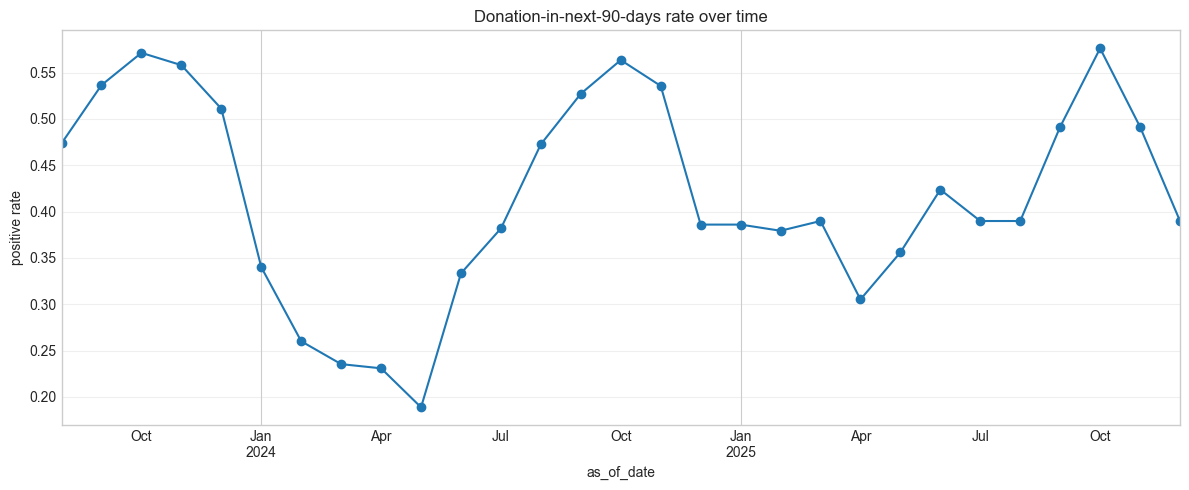

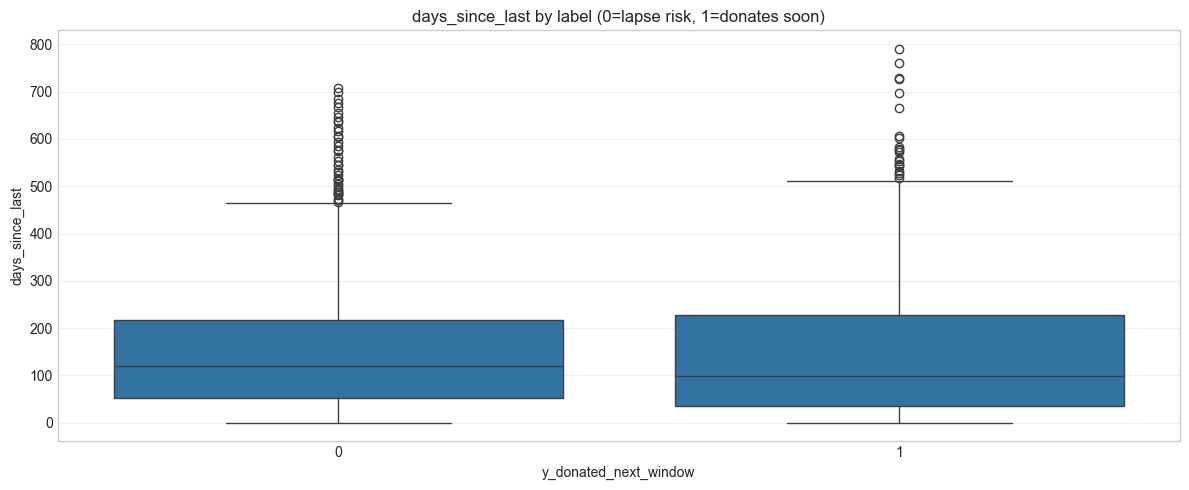

In [5]:
# Quick EDA: target rate over time
rate = snapshots.groupby("as_of_date")["y_donated_next_window"].mean()
ax = rate.plot(marker="o")
ax.set_title("Donation-in-next-90-days rate over time")
ax.set_ylabel("positive rate")
style_axes(ax)
plt.tight_layout()
plt.show()

# Most predictive-feeling single feature: days_since_last
if HAVE_SEABORN:
    tmp = snapshots.dropna(subset=["days_since_last"]).copy()
    ax = sns.boxplot(data=tmp, x="y_donated_next_window", y="days_since_last")
    ax.set_title("days_since_last by label (0=lapse risk, 1=donates soon)")
    style_axes(ax)
    plt.tight_layout()
    plt.show()

### 3) Modeling, feature selection, evaluation

We compare three candidates: an interpretable baseline (**logistic regression**), a tree ensemble (**random forest**), and a gradient-boosted tree model (**HistGradientBoostingClassifier**, HGB). The train/test split is **chronological** by `as_of_date` (earlier months → train, latest months → test).

**Hyperparameter tuning:** each algorithm is tuned with **RandomizedSearchCV** (`N_ITER` trials) using **group cross-validation by `supporter_id`**, so the same supporter does not appear in both train and validation folds (reduces correlation leakage). Scoring during search is **average precision** (aligned with PR-AUC).

**Auto-selection:** the winning algorithm is chosen by **higher CV score** (`best_score_` from the search, i.e. mean average precision across folds)—**not** by test PR-AUC, so the hold-out test set is only used for **reporting** generalization. The final model is then refit on all data for deployment scoring.

**Generalization caveat:** The chronological split separates **calendar time** (train months vs test months), but the **same supporter** can appear in **both** sets on **different** snapshot rows. Test metrics therefore describe “predict the next 90 days for donors we already have history on,” not **cold-start** supporters who never appear in training. Validating **brand-new** donors would require a different design (e.g. only first-ever snapshots).

#### Feature set and selection (Ch. 16)

**What we include (and why):** Features are built only from information **on or before** each snapshot’s `as_of_date`: RFM-style aggregates (recency, frequency, monetary summaries), **mix** features (shares of past donations by channel, campaign, donation type), and **static supporter attributes** from `supporters` (e.g. type, acquisition channel, geography). These are standard levers for describing donor engagement and are usable in a real scoring job.

**What we exclude (and why):** We drop identifiers and timestamps used only for joining or labeling (`supporter_id`, `as_of_date`, raw `donation_date_*`, target). Including them would either leak the label structure or be non-actionable at deployment.

**Selection approach:** We did not run an automated wrapper (e.g. recursive feature elimination) on the final ensemble. The feature count after one-hot encoding is moderate, and we rely on **regularized logistic regression**, **tree ensembles**, and **cross-validation** to limit overfitting. A reasonable next step would be to compare this full set against a smaller set (e.g. RFM-only) on the same validation protocol.


In [6]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, classification_report, log_loss, roc_auc_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.base import clone
from scipy.stats import loguniform

TARGET = "y_donated_next_window"
GROUP_TIME = "as_of_date"
GROUP_SUPPORTER = "supporter_id"

# Features: drop IDs + raw date columns (supporter_id kept in snapshots for grouping)
drop_cols = {"supporter_id", "as_of_date", TARGET, "donation_date_max", "donation_date_min"}
X = snapshots.drop(columns=[c for c in drop_cols if c in snapshots.columns])
y = snapshots[TARGET]


def split_chronological(snapshots_df: pd.DataFrame, test_frac: float = 0.25):
    """Train = earliest months; test = latest months (temporal, not random)."""
    months = np.sort(snapshots_df[GROUP_TIME].unique())
    n_test = max(1, int(np.ceil(len(months) * test_frac)))
    if len(months) <= n_test:
        n_test = max(1, len(months) // 4)
    train_months = set(months[:-n_test])
    test_months = set(months[-n_test:])
    if len(train_months) == 0:
        train_months = set(months[:1])
        test_months = set(months[1:])
    train_mask = snapshots_df[GROUP_TIME].isin(train_months)
    test_mask = snapshots_df[GROUP_TIME].isin(test_months)
    train_idx = np.flatnonzero(train_mask.to_numpy())
    test_idx = np.flatnonzero(test_mask.to_numpy())
    return train_idx, test_idx, train_months, test_months


train_idx, test_idx, train_months, test_months = split_chronological(snapshots, test_frac=0.25)
print(
    "Chronological split — train months:",
    len(train_months),
    "(earliest:", pd.Timestamp(min(train_months)).date(), ")",
    "| test months:",
    len(test_months),
    "(latest:", pd.Timestamp(max(test_months)).date(), ")",
)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

# dense output required for HistGradientBoostingClassifier (RF/logit also work with dense)
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_cols,
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)

logit = Pipeline(
    steps=[
        ("prep", preprocess),
        (
            "clf",
            LogisticRegression(
                solver="saga",
                max_iter=8000,
                class_weight="balanced",
            ),
        ),
    ]
)

rf = Pipeline(
    steps=[
        ("prep", preprocess),
        ("clf", RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced")),
    ]
)

hgb = Pipeline(
    steps=[
        ("prep", preprocess),
        (
            "clf",
            HistGradientBoostingClassifier(
                random_state=42,
                class_weight="balanced",
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10,
            ),
        ),
    ]
)

# Hyperparameter search + pick winner by CV only (test set is for reporting, not selection)
CV_SCORING = "average_precision"
N_ITER = 40  # random search trials per algorithm (more stable than very small N)

groups_cv = snapshots.loc[train_idx, GROUP_SUPPORTER].to_numpy()
n_groups_supp = int(np.unique(groups_cv).size)
if n_groups_supp >= 3:
    cv = GroupKFold(n_splits=min(3, n_groups_supp))
elif n_groups_supp == 2:
    cv = GroupKFold(n_splits=2)
else:
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_dist_logit = {
    "clf__C": loguniform(1e-4, 1e3),
    "clf__max_iter": [4000, 8000],
}

param_dist_rf = {
    "clf__n_estimators": [200, 400, 600],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_leaf": [1, 2, 4, 8],
    "clf__max_features": ["sqrt", "log2"],
}

param_dist_hgb = {
    "clf__max_iter": [100, 200, 400],
    "clf__learning_rate": loguniform(0.02, 0.3),
    "clf__max_depth": [None, 5, 10, 15],
    "clf__min_samples_leaf": [10, 20, 40],
    "clf__l2_regularization": [0.0, 0.1, 1.0],
}

logit_search = RandomizedSearchCV(
    clone(logit),
    param_distributions=param_dist_logit,
    n_iter=N_ITER,
    cv=cv,
    scoring=CV_SCORING,
    random_state=42,
    n_jobs=-1,
    refit=True,
)
rf_search = RandomizedSearchCV(
    clone(rf),
    param_distributions=param_dist_rf,
    n_iter=N_ITER,
    cv=cv,
    scoring=CV_SCORING,
    random_state=42,
    n_jobs=-1,
    refit=True,
)
hgb_search = RandomizedSearchCV(
    clone(hgb),
    param_distributions=param_dist_hgb,
    n_iter=N_ITER,
    cv=cv,
    scoring=CV_SCORING,
    random_state=42,
    n_jobs=-1,
    refit=True,
)

if isinstance(cv, GroupKFold):
    logit_search.fit(X_train, y_train, groups=groups_cv)
    rf_search.fit(X_train, y_train, groups=groups_cv)
    hgb_search.fit(X_train, y_train, groups=groups_cv)
else:
    logit_search.fit(X_train, y_train)
    rf_search.fit(X_train, y_train)
    hgb_search.fit(X_train, y_train)

searches = {"logit": logit_search, "random_forest": rf_search, "hist_gradient_boosting": hgb_search}

results = []
for name, search in searches.items():
    m = search.best_estimator_
    proba_mat = m.predict_proba(X_test)
    proba = proba_mat[:, 1]
    pred = (proba >= 0.5).astype(int)

    roc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)
    ll = log_loss(y_test, proba_mat)

    results.append(
        {
            "model": name,
            "roc_auc": roc,
            "pr_auc": pr,
            "log_loss": ll,
            "cv_best_score": search.best_score_,
            "test_n": len(y_test),
            "pos_rate_test": float(y_test.mean()),
            "best_params": search.best_params_,
        }
    )

    print("\n==", name, "(tuned) ==")
    print("best_params:", search.best_params_)
    print("CV best (average_precision):", search.best_score_)
    print("ROC-AUC (test):", roc)
    print("PR-AUC (test):", pr)
    print("Log loss (test, lower is better):", ll)
    print(classification_report(y_test, pred, digits=3))

# Choose algorithm by CV score only; tie-break: logit > random_forest > hist_gradient_boosting
MODEL_ORDER = ["logit", "random_forest", "hist_gradient_boosting"]
candidates = [
    ("logit", logit_search.best_score_),
    ("random_forest", rf_search.best_score_),
    ("hist_gradient_boosting", hgb_search.best_score_),
]
best_model_name = max(candidates, key=lambda x: (x[1], -MODEL_ORDER.index(x[0])))[0]
best_search = searches[best_model_name]

best_model = clone(best_search.best_estimator_)
results_df = pd.DataFrame(results).sort_values("cv_best_score", ascending=False)
results_df["selected_by_cv"] = results_df["model"] == best_model_name
print(
    "\n>>> Selected model:",
    best_model_name,
    "(higher mean CV average_precision; test metrics above are for reporting only)",
)
display(results_df)


Chronological split — train months: 21 (earliest: 2023-08-01 ) | test months: 8 (latest: 2025-12-01 )

== logit (tuned) ==
best_params: {'clf__C': np.float64(0.004132917911457902), 'clf__max_iter': 8000}
CV best (average_precision): 0.5549220567226268
ROC-AUC (test): 0.5408075836295688
PR-AUC (test): 0.5182840205276238
Log loss (test, lower is better): 0.7052593349647414
              precision    recall  f1-score   support

           0      0.577     0.509     0.541       265
           1      0.454     0.522     0.485       207

    accuracy                          0.515       472
   macro avg      0.515     0.516     0.513       472
weighted avg      0.523     0.515     0.517       472


== random_forest (tuned) ==
best_params: {'clf__n_estimators': 400, 'clf__min_samples_leaf': 8, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
CV best (average_precision): 0.5253059725985986
ROC-AUC (test): 0.5490930635311274
PR-AUC (test): 0.5349159841784644
Log loss (test, lower is better): 

,model,roc_auc,pr_auc,log_loss,cv_best_score,test_n,pos_rate_test,best_params,selected_by_cv
0,logit,0.540808,0.518284,0.705259,0.554922,472,0.438559,"{'clf__C': 0.004132917911457902, 'clf__max_ite...",True
1,random_forest,0.549093,0.534916,0.729675,0.525306,472,0.438559,"{'clf__n_estimators': 400, 'clf__min_samples_l...",False
2,hist_gradient_boosting,0.545875,0.532185,0.724115,0.496721,472,0.438559,"{'clf__l2_regularization': 0.1, 'clf__learning...",False


#### Evaluation: metrics, errors in context, and fairness

The following interprets the **test** metrics printed in the modeling cell above (those are the unbiased chronological evaluation). A **later** code cell refits the chosen model on **all** snapshot rows—including months that were in the test window—to produce deployment-style scores; that refit is **not** used to claim fresh generalization error.

**Metrics:** We report **ROC-AUC**, **PR-AUC**, and **log loss** on the chronological test window. **PR-AUC** (aligned with **average precision** in tuning) emphasizes ranking who is likely to donate soon. **Log loss** penalizes confident wrong probabilities and reflects **calibration** of `predict_proba` (lower is better).

**Calibration / threshold:** The `classification_report` in the modeling cell uses a **0.5** probability cutoff by default. That cutoff is **illustrative only**, not a recommended operating rule. In production, choose **top‑K** outreach lists (fixed list size) and/or a **cost-sensitive** threshold from staff capacity and the relative cost of false positives vs false negatives.

**False positives vs false negatives (using 0.5 only to mirror the printed report):**
- **False positive** — Model predicts a donation in the next 90 days when none occurs. *Cost:* staff time on lower-priority outreach; possible donor fatigue if over-contacted.
- **False negative** — Model misses someone who would have donated (or who is quietly disengaging). *Cost:* missed revenue and weaker relationship maintenance.

Because fundraising outreach is **capacity-constrained**, the practical use case is often a **ranked list** (contact the top *K* “at risk” or “best opportunity” supporters), not a single universal threshold — so we emphasize ranking quality (PR-AUC) and discuss tradeoffs in business terms, not only accuracy at 0.5.

**Fairness:** We did **not** stratify model performance or error rates by donor segments (e.g. region, acquisition channel, supporter type). A production system should **monitor** scores and outcomes across segments over time to ensure outreach policies do not systematically disadvantage any group. That monitoring is outside the scope of this notebook but should be planned before high-stakes use.


In [7]:
# Which supporters would we contact right now?
# Build a "current" snapshot at the latest date we can score (max_date - 90 days)
latest_score_date = max_date - pd.Timedelta(days=90)
current = build_snapshot(latest_score_date)

X_cur = current.drop(columns=[c for c in drop_cols if c in current.columns])

# best_model_name + best_model were set in the modeling cell (unfitted clone of the CV winner).
# Refit on ALL snapshot rows (including months that were in the held-out test window) only for deployment-style scores.
# Do not treat predictions from this fit as another unbiased test evaluation — use the test metrics printed earlier.
best_model.fit(X, y)
current["p_donate_next_90d"] = best_model.predict_proba(X_cur)[:, 1]
current["p_lapse_next_90d"] = 1 - current["p_donate_next_90d"]

cols = [c for c in ["supporter_id", "supporter_type", "acquisition_channel", "days_since_last", "donation_date_count", "amount_sum", "p_lapse_next_90d"] if c in current.columns]

display(current.sort_values("p_lapse_next_90d", ascending=False)[cols].head(15))

,supporter_id,supporter_type,acquisition_channel,days_since_last,donation_date_count,amount_sum,p_lapse_next_90d
13,14,MonetaryDonor,WordOfMouth,707,1,0.00,0.653145
47,49,SkillsContributor,Website,140,2,0.00,0.639586
28,30,InKindDonor,SocialMedia,125,2,4713.84,0.617611
14,15,SkillsContributor,Website,442,2,925.66,0.613035
15,16,InKindDonor,Website,28,5,1718.04,0.600765
4,5,InKindDonor,Website,60,5,4738.58,0.597409
21,22,SkillsContributor,WordOfMouth,18,4,2188.82,0.594243
55,57,InKindDonor,SocialMedia,727,1,1194.06,0.591706
54,56,SkillsContributor,Church,19,3,593.89,0.582926
35,37,InKindDonor,Website,323,5,1934.92,0.579803


### 4) Causal and relationship analysis

This pipeline is **primarily predictive** (who is likely to donate in the next 90 days). The textbook still asks for an honest discussion of **relationships** in the data and what can (and cannot) be claimed about **cause and effect**.

**What the data and model tend to highlight (associational):** Strong predictors often include **recency** (`days_since_last`), **frequency / tenure** (how long and how often the supporter has given), and **channel or campaign mix** — patterns consistent with how nonprofits see engagement decay and campaign response. If the winning model is linear, inspect **coefficients** (sign/magnitude after scaling); if tree-based, **feature importances** are a rough relative ranking, not an effect size in dollars.

**Do these relationships make theoretical sense?** Yes at a high level: more recent, more frequent donors are usually more likely to give again soon. That does **not** prove that “increasing tenure causes gifts” or that changing a label like `supporter_type` changes behavior — those are **confounded** by history, self-selection, and unobserved factors.

**What we do *not* claim:** We do **not** treat predictive accuracy as **causal evidence**. A high score does not mean “if we intervene, they will donate”; it means **similar supporters in the past** often showed the outcome. **Correlation is not causation.**

**Reasonable operational actions (without causal proof):** Use scores to **prioritize** who gets personal outreach, **test** messaging or timing, and **measure** results in experiments or A/B tests. If `days_since_last` is high, staff cannot “fix recency” directly — they can **reach out** and **track** whether engagement improves. That is **decision support**, not a proven intervention effect.

**Limitations:** We observe **donation records**, not full donor psychology or external events. Any “causal story” here is **hypothesis-generating** for leadership, not a substitute for randomized evaluation of programs.


,coefficient
is_recurring_mean,0.225654
donation_date_count,0.103177
acquisition_channel_WordOfMouth,-0.097451
supporter_type_MonetaryDonor,0.085417
region_Visayas,0.071614
share_donation_type_Skills,0.069270
supporter_type_InKindDonor,-0.064842
share_channel_source_PartnerReferral,-0.063708
relationship_type_Local,0.063091
acquisition_channel_Event,0.050000


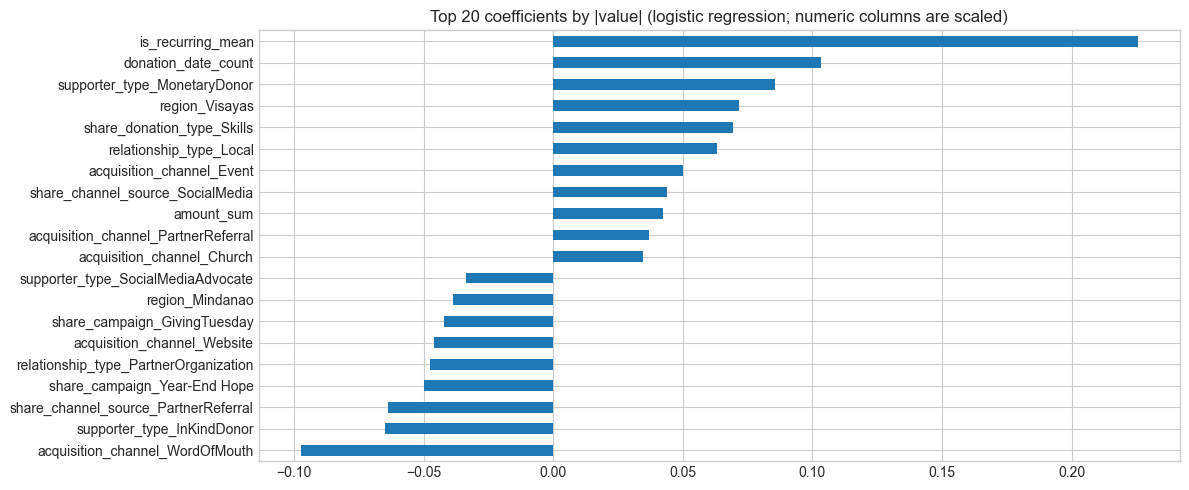

In [8]:
# Interpretability: tree models use feature_importances_; logistic regression uses signed coefficients (after prep).

def _feature_names_after_prep(prep, num_cols, cat_cols):
    cat_ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    return list(num_cols) + list(cat_ohe.get_feature_names_out(cat_cols))


best_name = str(best_model_name)
TREE_MODELS = {"random_forest", "hist_gradient_boosting"}

if best_name in TREE_MODELS:
    prep = best_model.named_steps["prep"]
    clf = best_model.named_steps["clf"]
    feat_names = _feature_names_after_prep(prep, num_cols, cat_cols)

    importances = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)
    display(importances.head(20).to_frame("importance"))

    label = "random forest" if best_name == "random_forest" else "hist gradient boosting"
    ax = importances.head(20).sort_values().plot(kind="barh")
    ax.set_title(f"Top 20 feature importances ({label})")
    plt.tight_layout()
    plt.show()

elif best_name == "logit":
    prep = best_model.named_steps["prep"]
    clf = best_model.named_steps["clf"]
    feat_names = _feature_names_after_prep(prep, num_cols, cat_cols)
    coef = pd.Series(clf.coef_.ravel(), index=feat_names)
    top = coef.reindex(coef.abs().sort_values(ascending=False).head(20).index)
    display(top.to_frame("coefficient"))
    ax = top.sort_values().plot(kind="barh")
    ax.set_title("Top 20 coefficients by |value| (logistic regression; numeric columns are scaled)")
    plt.tight_layout()
    plt.show()

else:
    print("Unknown best_model_name; cannot plot importances or coefficients.")

**Metrics show a modest lift over random / naive baselines; the model may help rank outreach slightly but should not be treated as high-confidence forecasting.**